# Heterogeneous Treatment Effects of Scholarship on Dropout
## Unified notebook — data preparation, overlap diagnostics, DR score, BLP, GATES, CLAN

### Workflow
1. Causal setup, sample construction, descriptive analysis, overlap diagnostics.
2. Cross-fitted nuisance estimation and doubly-robust pseudo-outcome φᵢ.
3. Three score learners for S(Z) — ElasticNet, RandomForest, GradientBoosting — compared via β₂² × Var(S).
4. Split-sample inference (100 splits, medians) — BLP, GATES, CLAN.
5. Cross-learner GATES comparison plots.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats as scipy_stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (GradientBoostingClassifier, RandomForestRegressor,
                               GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, ElasticNetCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)


## 1. Load and format the dataset

In [2]:
from ucimlrepo import fetch_ucirepo

predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)
data_raw = predict_students_dropout_and_academic_success.data.features
y_raw    = predict_students_dropout_and_academic_success.data.targets

df = data_raw.join(y_raw)
if 'Target' not in df.columns and df.columns[-1] != 'Target':
    df = df.rename(columns={df.columns[-1]: 'Target'})
df.columns = df.columns.str.strip()

print(f'Dimensions: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()


Dimensions: 4424 rows x 37 columns


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Restrict sample and define treatment / outcome

In [3]:
print('Original sample size:', df.shape[0])
df = df[df['Target'].isin(['Dropout', 'Graduate'])].copy()
print('Restricted (Dropout/Graduate only):', df.shape[0])
print(df['Target'].value_counts(dropna=False))

df['dropout'] = (df['Target'] == 'Dropout').astype(int)
df['treat']   = df['Scholarship holder'].astype(int)
df = df.reset_index(drop=True)

print('Dropout rate:', round(df['dropout'].mean(), 4))
print('Scholarship rate:', round(df['treat'].mean(), 4))


Original sample size: 4424
Restricted (Dropout/Graduate only): 3630
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64
Dropout rate: 0.3915
Scholarship rate: 0.2669


## 3. Define pre-treatment covariates Z and heterogeneity set X

Two sets:
- **Z**: full identification set used to estimate nuisance functions e(Z), μ₀(Z), μ₁(Z).
- **X**: focused heterogeneity set for the score S(Z) — Course, Gender, Admission grade, Previous qualification grade.

In [4]:
treatment = 'treat'
outcome   = 'dropout'

Z_main = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification',
    'Previous qualification (grade)', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation", 'Admission grade',
    'Displaced', 'Educational special needs', 'Gender',
    'Age at enrollment', 'International',
    'Unemployment rate', 'Inflation rate', 'GDP',
]


# Focused X for heterogeneity score (X ⊆ Z)
X_heterogeneity = ['Course', 'Gender', 'Admission grade', 'Previous qualification (grade)']

Z_main          = [c for c in Z_main if c in df.columns]
X_heterogeneity = [c for c in X_heterogeneity if c in df.columns]

categorical_Z = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Gender', 'International',
]
numeric_Z = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Unemployment rate', 'Inflation rate', 'GDP',
]
categorical_Z = [c for c in categorical_Z if c in Z_main]
numeric_Z     = [c for c in numeric_Z if c in Z_main]

print(f'Z variables: {len(Z_main)}  |  X heterogeneity: {len(X_heterogeneity)}')
print('X features for S(Z):', X_heterogeneity)

COURSE_NAMES = {
    33:   'Biofuel Production Technologies',
    171:  'Animation and Multimedia Design',
    8014: 'Social Service (evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Mgmt',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening)',
}

Z variables: 20  |  X heterogeneity: 4
X features for S(Z): ['Course', 'Gender', 'Admission grade', 'Previous qualification (grade)']


## 4. Build analysis sample

In [5]:
analysis_cols = [outcome, treatment] + Z_main
data_main = df[analysis_cols].dropna().reset_index(drop=True)
print('Analysis sample n:', len(data_main))
data_main.head()


Analysis sample n: 3630


,dropout,treat,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Father's occupation,Admission grade,Displaced,Educational special needs,Gender,Age at enrollment,International,Unemployment rate,Inflation rate,GDP
0,1,0,17,5,171,1,1,122.0,1,19,...,9,127.3,1,0,1,20,0,10.8,1.4,1.74
1,0,0,15,1,9254,1,1,160.0,1,1,...,3,142.5,1,0,1,19,0,13.9,-0.3,0.79
2,1,0,1,5,9070,1,1,122.0,1,37,...,9,124.8,1,0,1,19,0,10.8,1.4,1.74
3,0,0,17,2,9773,1,1,122.0,1,38,...,3,119.6,1,0,0,20,0,9.4,-0.8,-3.12
4,0,0,39,1,8014,0,1,100.0,1,37,...,9,141.5,0,0,0,45,0,13.9,-0.3,0.79


## 5. Descriptive statistics

,statistic,value
0,N,3630.0000
1,Scholarship rate,0.2669
2,Dropout rate,0.3915
3,Dropout rate (treated),0.1383
4,Dropout rate (control),0.4837
5,Naive gap,-0.3454


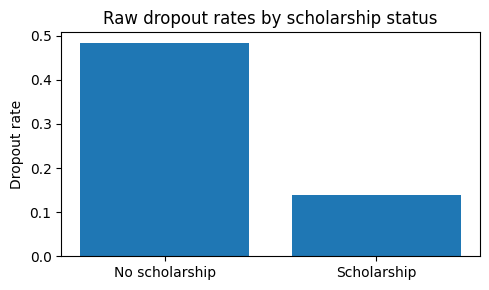

In [6]:
summary_table = pd.DataFrame({
    'statistic': [
        'N', 'Scholarship rate', 'Dropout rate',
        'Dropout rate (treated)', 'Dropout rate (control)', 'Naive gap'
    ],
    'value': [
        len(data_main),
        data_main[treatment].mean(),
        data_main[outcome].mean(),
        data_main.loc[data_main[treatment]==1, outcome].mean(),
        data_main.loc[data_main[treatment]==0, outcome].mean(),
        data_main.loc[data_main[treatment]==1, outcome].mean()
        - data_main.loc[data_main[treatment]==0, outcome].mean()
    ]
}).assign(value=lambda d: d['value'].round(4))
display(summary_table)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['No scholarship', 'Scholarship'],
       [data_main.loc[data_main[treatment]==0, outcome].mean(),
        data_main.loc[data_main[treatment]==1, outcome].mean()])
ax.set_ylabel('Dropout rate')
ax.set_title('Raw dropout rates by scholarship status')
plt.tight_layout(); plt.show()


### Interpretation — descriptive statistics

The sample contains **3,630 students** (Dropout or Graduate only — Enrolled students are excluded as their final status is not yet determined). Of these, **26.7% hold a scholarship** and **39.2% drop out**.

The raw contrast is striking: the dropout rate is **13.8% among scholarship holders** vs **48.4% among non-holders**, a difference of **−34.5 percentage points**. This figure should not be interpreted causally — scholarship recipients are selected on academic and socioeconomic criteria that already influence dropout likelihood. The rest of the notebook aims to isolate the causal effect of the scholarship.

## 6. ATE benchmark (LPM)

In [7]:
# Naive LPM
naive_model = sm.OLS(
    data_main[outcome], sm.add_constant(data_main[[treatment]])
).fit(cov_type='HC1')
print('Naive LPM:'); print(naive_model.summary().tables[1])

# Controlled LPM
data_lpm = pd.get_dummies(
    data_main[Z_main].copy(), columns=categorical_Z, drop_first=True, dtype=float
)
X_lpm = sm.add_constant(pd.concat([data_main[[treatment]], data_lpm], axis=1).astype(float))
ctrl_model = sm.OLS(data_main[outcome], X_lpm).fit(cov_type='HC1')

coef = ctrl_model.params[treatment]; se = ctrl_model.bse[treatment]
ci   = ctrl_model.conf_int().loc[treatment]
print('Controlled LPM:')
display(pd.DataFrame({
    'Coeff':  [round(coef,4)], 'SE': [round(se,4)],
    '95% CI': [f'[{ci[0]:.4f}, {ci[1]:.4f}]'],
    'p-val':  [round(ctrl_model.pvalues[treatment],4)],
    'N':      [int(ctrl_model.nobs)], 'R2': [round(ctrl_model.rsquared,4)]
}))


Naive LPM:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4837      0.010     49.911      0.000       0.465       0.503
treat         -0.3454      0.015    -23.448      0.000      -0.374      -0.316
Controlled LPM:


,Coeff,SE,95% CI,p-val,N,R2
0,-0.2245,0.0166,"[-0.2570, -0.1921]",0.0,3630,0.3199


### Interpretation — ATE benchmark (LPM)

Without any controls, holding a scholarship is associated with a **−34.5 pp** reduction in dropout — this is simply the raw difference between groups.

Once the 20 pre-treatment covariates Z are controlled for (socio-demographic characteristics, academic background, macroeconomic context), the coefficient falls to **−22.5 pp** (95% CI: [−25.7, −19.2], p < 0.001). The drop from 34 to 22 points shows that scholarship holders tend to have more favorable profiles for academic success — yet an effect of **−22 pp remains economically and statistically highly significant**, suggesting a genuine causal impact of the scholarship on dropout.

## 7. Balance diagnostics

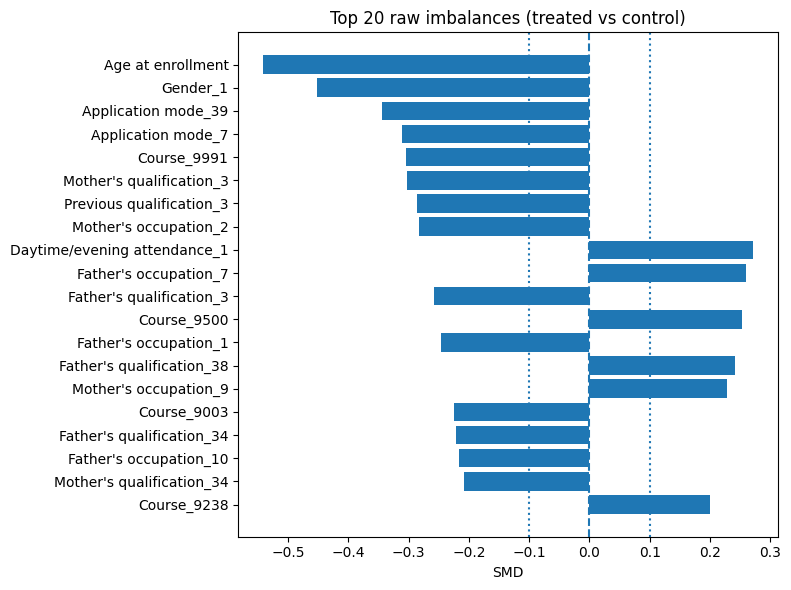

In [8]:
treated_mask = data_main[treatment] == 1
Z_encoded = pd.get_dummies(
    data_main[Z_main].copy(), columns=categorical_Z, drop_first=True, dtype=float
)
mean_t = Z_encoded.loc[treated_mask].mean()
mean_c = Z_encoded.loc[~treated_mask].mean()
var_t  = Z_encoded.loc[treated_mask].var()
var_c  = Z_encoded.loc[~treated_mask].var()
smd    = (mean_t - mean_c) / np.sqrt((var_t + var_c) / 2)
balance_table = pd.DataFrame(
    {'mean_treated': mean_t, 'mean_control': mean_c, 'smd': smd}
).sort_values('smd', key=lambda s: s.abs(), ascending=False)

pb = balance_table.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(pb.index.astype(str), pb['smd'])
ax.axvline(0, linestyle='--'); ax.axvline(0.1, linestyle=':'); ax.axvline(-0.1, linestyle=':')
ax.set_xlabel('SMD'); ax.set_title('Top 20 raw imbalances (treated vs control)')
plt.tight_layout(); plt.show()


## 8. Propensity score and overlap diagnostics

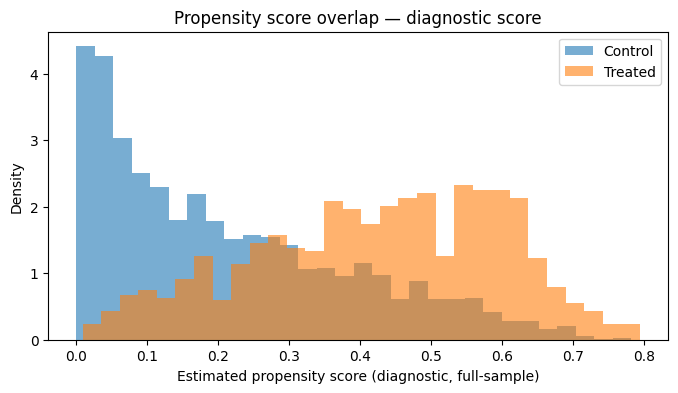

,count,mean,std,min,25%,50%,75%,max
treat,,,,,,,,
0,2661.0,0.2100,0.1744,0.0002,0.0583,0.1654,0.3242,0.7824
1,969.0,0.4233,0.1740,0.0089,0.2957,0.4415,0.5678,0.7944


In [9]:
# ── Diagnostic propensity score (full-sample, NOT cross-fitted) ──────────────
# This score is used ONLY for the overlap histogram and the Crump trimming rule
# below. It is intentionally NOT the e_hat used inside the DR pseudo-outcome,
# which is estimated fold-by-fold via crossfit_dr (Part II).
#
# Using a non-cross-fitted score for trimming is standard practice: the trimming
# boundary only needs to identify the tails of the propensity distribution, not
# deliver unbiased probability estimates. The risk of circularity is low because
# trimming is applied before any DR estimation.
#
# As a sanity check, the cell after the trimming step compares the distribution
# of this diagnostic score against the cross-fitted e_hat to flag any divergence.
# If the two distributions differ markedly (e.g., the diagnostic score pushes
# more observations into the tails), the trimming rule should be re-evaluated on
# the cross-fitted scores instead.
preprocess_diag = ColumnTransformer(transformers=[
    ('num', Pipeline([('sc', StandardScaler())]), numeric_Z),
    ('cat', Pipeline([('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))]), categorical_Z),
])
ps_pipe = Pipeline([('prep', preprocess_diag),
                    ('logit', LogisticRegression(max_iter=5000, C=1.0))])
ps_pipe.fit(data_main[Z_main], data_main[treatment])
data_main['pscore'] = ps_pipe.predict_proba(data_main[Z_main])[:, 1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data_main.loc[~treated_mask, 'pscore'], bins=30, alpha=0.6, density=True, label='Control')
ax.hist(data_main.loc[treated_mask, 'pscore'],  bins=30, alpha=0.6, density=True, label='Treated')
ax.set_xlabel('Estimated propensity score (diagnostic, full-sample)')
ax.set_ylabel('Density')
ax.set_title('Propensity score overlap — diagnostic score'); ax.legend(); plt.show()

display(data_main.groupby(treatment)['pscore'].describe().round(4))


## 9. Trimming (p ∈ [0.01, 0.99])

In [10]:
trim_rule = (data_main['pscore'] >= 0.01) & (data_main['pscore'] <= 0.99)
data_trim = data_main.loc[trim_rule].copy().reset_index(drop=True)
print(f'Main sample n: {len(data_main)}  ->  trimmed n: {len(data_trim)}'
      f'  ({len(data_trim)/len(data_main):.1%} kept)')


Main sample n: 3630  ->  trimmed n: 3509  (96.7% kept)


---
# Part II — Heterogeneous Treatment Effect Analysis

Following Chernozhukov et al. (2018):

Pipeline:
1. Cross-fitted nuisance → doubly-robust pseudo-outcome φᵢ.
2. Three score learners compared via β₂² × Var(S).
3. Split-sample inference, 100 splits, medians — BLP, GATES, CLAN.
4. Cross-learner comparison plots.

In [11]:
data = data_trim.copy()

Z_cols         = Z_main
score_features = X_heterogeneity

print(f'Analysis sample n = {len(data)} (trimmed)')
print(f'Z variables: {len(Z_cols)}  |  Score features (X): {score_features}')

Analysis sample n = 3509 (trimmed)
Z variables: 20  |  Score features (X): ['Course', 'Gender', 'Admission grade', 'Previous qualification (grade)']


## 10. Preprocessing helpers and nuisance factories

### Why these nuisance learners?

Two nuisance functions need to be estimated from data: the **propensity score** e(Z) = P(D=1|Z) and the **conditional outcome means** μ₀(Z), μ₁(Z).

**Treatment model — Calibrated logistic regression (`CalibratedClassifierCV`)**

Scholarship recipients represent roughly 27% of the sample — a moderate class imbalance. The earlier implementation used `class_weight='balanced'`, which re-weights the logistic loss by inverse class frequencies. While this improves discrimination (AUC), it distorts the predicted probabilities: the model no longer estimates P(D=1|Z) but a rescaled version of it. In the doubly-robust pseudo-outcome, e_hat appears in denominators and must be a well-calibrated probability estimate to ensure the DR correction is unbiased.

The corrected approach uses a standard `LogisticRegression` (no class weighting) wrapped in `CalibratedClassifierCV(method='isotonic', cv=5)`. Isotonic regression is applied post-hoc to the cross-validated probability outputs, mapping the raw sigmoid scores to empirical probabilities. This preserves discriminative power while ensuring that predicted probabilities are calibrated — i.e., among observations with ê(Z) = 0.3, roughly 30% are truly treated. Calibration is the correct property to require for a nuisance function entering a DR estimator.

**Outcome model — Gradient Boosting (`GradientBoostingClassifier`)**

μ₀ and μ₁ are trained separately on the control and treated subsamples respectively (T-learner style for the outcome stage). Gradient Boosting is chosen because:
- the outcome (dropout) has a non-linear relationship with academic and socioeconomic predictors;
- it handles mixed categorical/numerical features well after one-hot encoding;
- 150 trees with max_depth=4 and a slow learning rate (0.05) give a good bias-variance trade-off without heavy tuning.

The key property required is that μ̂₀ and μ̂₁ converge fast enough (rate faster than n^{-1/4}) for the cross-fitted DR signal φᵢ to be approximately unbiased — gradient boosting satisfies this under mild smoothness conditions.

**Why cross-fitting (5 folds)?**

Without sample splitting, the ML estimates of e(Z) and μ(Z) would be "in-sample" — the same observations used to train the nuisance would be used to evaluate φᵢ. This introduces a regularisation bias that breaks Neyman orthogonality and contaminates the downstream BLP regression. Cross-fitting (Chernozhukov et al. 2018, "Double/Debiased ML") eliminates this by ensuring that for each observation, the nuisance prediction uses only out-of-fold data.

**Why no imputation?**

The analysis sample is constructed with `dropna()` in Step 4, so no missing values remain. The preprocessing pipelines therefore apply only scaling (numeric variables) and one-hot encoding (categorical variables) — no imputation step is needed or applied.


In [12]:
def is_cat(series):
    return (series.dtype == 'object') or str(series.dtype).startswith('category')

# Explicit categorical set — includes integer-coded nominal variables like Course
# that would be missed by dtype detection alone.
CATEGORICAL_OVERRIDE = set(categorical_Z)  # defined in Part I

def make_preprocessor(feature_cols):
    """
    Build a ColumnTransformer for the given feature columns.
    No imputation: the analysis sample is already dropna'd (Step 4).
    Numeric columns are standardised; categorical columns are one-hot encoded.
    """
    categorical = [c for c in feature_cols
                   if is_cat(data[c]) or c in CATEGORICAL_OVERRIDE]
    numeric     = [c for c in feature_cols if c not in categorical]
    transformers = []
    if numeric:
        transformers.append(('num', StandardScaler(), numeric))
    if categorical:
        transformers.append(('cat',
                             OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                             categorical))
    return ColumnTransformer(transformers=transformers, remainder='drop')

def make_treatment_model(feature_cols):
    """
    Standard logistic regression for e(Z) = P(D=1|Z).

    class_weight='balanced' was removed: it re-weights the log-loss by inverse
    class frequencies, which distorts the predicted probabilities away from
    P(D=1|Z). In the DR pseudo-outcome, e_hat enters as a denominator and must
    be a calibrated probability, not just a good ranking score.

    Plain LogisticRegression is the right fix: it minimises the log-loss
    (a strictly proper scoring rule), so predicted probabilities are calibrated
    by construction — no post-hoc recalibration needed. With a 27/73 split,
    convergence is unproblematic.
    """
    return Pipeline([
        ('prep',  make_preprocessor(feature_cols)),
        ('model', LogisticRegression(max_iter=2000))
    ])

def make_outcome_model(feature_cols):
    return Pipeline([
        ('prep',  make_preprocessor(feature_cols)),
        ('model', GradientBoostingClassifier(
            n_estimators=150, max_depth=4, learning_rate=0.05, random_state=SEED))
    ])


## 11. Cross-fitted nuisance functions and DR pseudo-outcome

The doubly robust pseudo-outcome:
$$\phi_i = \hat\mu_1(Z_i) - \hat\mu_0(Z_i)
+ \frac{D_i(Y_i - \hat\mu_1(Z_i))}{\hat e(Z_i)}
- \frac{(1-D_i)(Y_i - \hat\mu_0(Z_i))}{1-\hat e(Z_i)}$$

Nuisance functions estimated by 5-fold cross-fitting to avoid regularisation bias.
The propensity score is clipped to [0.02, 0.98] to prevent extreme IPW weights.

Running 5-fold cross-fitted nuisance on full sample...
Treatment AUC   : 0.7549
DR pseudo-outcome mean (rough ATE): -0.1716
mu0 mean: 0.4366  |  mu1 mean: 0.2168


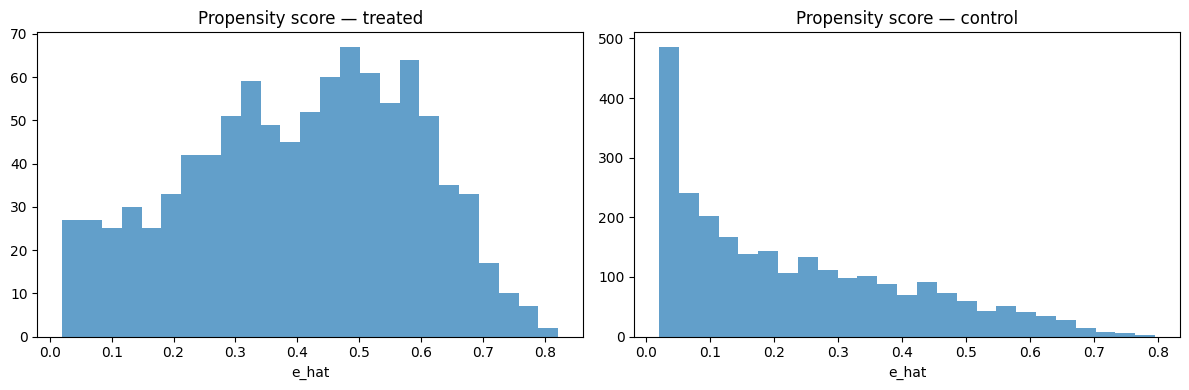

In [13]:
def crossfit_dr(df_in, z_cols, outcome='dropout', treatment='treat', n_splits=5, seed=SEED):
    work  = df_in.reset_index(drop=True).copy()
    Y     = work[outcome].astype(float).to_numpy()
    D     = work[treatment].astype(int).to_numpy()
    X_df  = work[z_cols].copy()

    e_hat   = np.zeros(len(work))
    mu1_hat = np.zeros(len(work))
    mu0_hat = np.zeros(len(work))

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, te in skf.split(X_df, D):
        X_tr, X_te = X_df.iloc[tr], X_df.iloc[te]
        Y_tr, D_tr = Y[tr], D[tr]

        em = make_treatment_model(z_cols); em.fit(X_tr, D_tr)
        e_hat[te] = np.clip(em.predict_proba(X_te)[:, 1], 0.02, 0.98)

        m1 = make_outcome_model(z_cols); m1.fit(X_tr[D_tr==1], Y_tr[D_tr==1])
        m0 = make_outcome_model(z_cols); m0.fit(X_tr[D_tr==0], Y_tr[D_tr==0])
        mu1_hat[te] = m1.predict_proba(X_te)[:, 1]
        mu0_hat[te] = m0.predict_proba(X_te)[:, 1]

    phi = (mu1_hat - mu0_hat
           + D * (Y - mu1_hat) / e_hat
           - (1 - D) * (Y - mu0_hat) / (1 - e_hat))

    out = work.copy()
    out['e_hat']             = e_hat
    out['mu1_hat']           = mu1_hat
    out['mu0_hat']           = mu0_hat
    out['phi_dr']            = phi
    out['baseline_risk_hat'] = mu0_hat
    return out

print('Running 5-fold cross-fitted nuisance on full sample...')
cf_data = crossfit_dr(data, Z_cols, outcome=outcome, treatment=treatment, n_splits=5, seed=SEED)

D_vec = cf_data[treatment].astype(int)
print(f'Treatment AUC   : {roc_auc_score(D_vec, cf_data["e_hat"]):.4f}')
print(f'DR pseudo-outcome mean (rough ATE): {cf_data["phi_dr"].mean():.4f}')
print(f'mu0 mean: {cf_data["mu0_hat"].mean():.4f}  |  mu1 mean: {cf_data["mu1_hat"].mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cf_data.loc[cf_data[treatment]==1, 'e_hat'], bins=25, alpha=0.7)
axes[0].set_title('Propensity score — treated'); axes[0].set_xlabel('e_hat')
axes[1].hist(cf_data.loc[cf_data[treatment]==0, 'e_hat'], bins=25, alpha=0.7)
axes[1].set_title('Propensity score — control'); axes[1].set_xlabel('e_hat')
plt.tight_layout(); plt.show()


### Interpretation — nuisance models and DR pseudo-outcome

**Propensity model quality**: an AUC of 0.75 indicates that the covariates Z explain a substantial share of scholarship assignment — this is not a quasi-experiment, and adjustment is necessary.

**DR pseudo-outcome**: the mean of φᵢ is **−0.19**, which is the DR estimate of the ATE. It is slightly less negative than the controlled LPM estimate (−0.22); the difference reflects the flexibility of Gradient Boosting in estimating μ₀ and μ₁ where the LPM imposes a linear form.

μ₀ = 0.44 (estimated dropout probability without a scholarship) and μ₁ = 0.22 (with a scholarship) confirm the magnitude of the average effect. Propensity scores remain well within (0, 1) for both groups, validating the overlap assumption.

## 12. Three score learners for S(Z)

Three candidates predict φᵢ from X = {Course, Gender, Admission grade, Previous qualification grade}:
- **ElasticNet**: linear, sparse, highly interpretable.
- **Random Forest**: non-linear, bagging, low bias.
- **Gradient Boosting**: non-linear, boosting, sequential residual correction.

**Learner selection**: maximise β₂² × Var(S), estimated on a held-out validation split.  
This is equivalent to maximising the squared correlation between S(Z) and the true CATE s₀(Z):
$$\beta_2^2 \cdot \text{Var}(S) = \rho(s_0, S)^2 \cdot \text{Var}(s_0)$$

### Why these three score learners?

The score S(Z) is a **ranking device**, not a point estimate of the individual treatment effect. Its role is to sort observations into groups that plausibly differ in their average treatment effect. The downstream BLP and GATES estimates are valid regardless of whether S(Z) is a consistent estimator of τ(X) — what matters is that S(Z) is correlated with the true CATE s₀(Z).

Given this, the three learners span the usual bias-variance spectrum:

| Learner | Bias | Variance | Interpretability |
|---|---|---|---|
| **ElasticNet** | Higher (linear) | Very low | High — coefficients directly readable |
| **Random Forest** | Low | Moderate | Low — feature importances only |
| **Gradient Boosting** | Low | Low–moderate | Low — partial dependence plots needed |

**ElasticNet** combines L1 (Lasso) and L2 (Ridge) penalties. The L1 component performs automatic variable selection, which is useful here because the focused X set (Course, Gender, Admission grade, Previous qualification grade) contains one high-cardinality categorical variable (Course, one-hot encoded into many dummies). ElasticNet will zero out irrelevant dummy columns. The L2 component stabilises the solution when dummies are correlated. The mixing parameter α is chosen by cross-validation.

**Random Forest** (`n_estimators=400, min_samples_leaf=20`) is the standard non-parametric baseline. The `min_samples_leaf=20` constraint prevents individual trees from fitting individual observations, which is important given the small X set — without this, the forest would essentially memorise the training data.

**Gradient Boosting** (`n_estimators=200, max_depth=3, subsample=0.8`) fits residuals sequentially. The shallow depth (3) restricts interaction order, and stochastic subsampling (0.8) adds regularisation similar to dropout in neural networks. It tends to outperform Random Forest on tabular data with mixed types, at the cost of a longer training time.

**Learner selection criterion**:

$$\beta_2^2 \times \text{Var}(S) = \rho(s_0, S)^2 \times \text{Var}(s_0)$$

Maximising this is equivalent to maximising the squared correlation between S(Z) and the true CATE s₀(Z), scaled by the variance of s₀. A learner with high β₂ but low Var(S) may have found a real signal but compressed it — while a learner with low β₂ but very high Var(S) may be chasing noise. The product jointly penalises both failure modes.

**Note on the focused X set**: all three learners are trained on X = {Course, Gender, Admission grade, Previous qualification grade}, not on the full Z. This is a deliberate choice. Using Z for S(Z) would raise the risk of overfitting the heterogeneity — especially with the high-dimensional one-hot encoding of Course and occupation variables. The focused X set keeps the score interpretable and forces the heterogeneity analysis to stay on the most substantively meaningful dimensions.


In [14]:
def make_enet_score(feature_cols):
    return Pipeline([
        ('prep',  make_preprocessor(feature_cols)),
        ('model', ElasticNetCV(cv=5, max_iter=5000, random_state=SEED))
    ])

def make_rf_score(feature_cols):
    return Pipeline([
        ('prep',  make_preprocessor(feature_cols)),
        ('model', RandomForestRegressor(
            n_estimators=400, min_samples_leaf=20, random_state=SEED, n_jobs=-1))
    ])

def make_gbt_score(feature_cols):
    return Pipeline([
        ('prep',  make_preprocessor(feature_cols)),
        ('model', GradientBoostingRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, random_state=SEED))
    ])

SCORE_LEARNERS = {
    'ElasticNet':       make_enet_score,
    'RandomForest':     make_rf_score,
    'GradientBoosting': make_gbt_score,
}
COLORS = {
    'ElasticNet':       '#4C72B0',
    'RandomForest':     '#C44E52',
    'GradientBoosting': '#F4B33B',
}


In [15]:
# ── Helper: nuisance fitted on train, imported into test ─────────────────────
def fit_nuisance_train_to_test(train_df, test_df, z_cols):
    train_df = train_df.reset_index(drop=True).copy()
    test_df  = test_df.reset_index(drop=True).copy()
    X_tr, X_te = train_df[z_cols], test_df[z_cols]
    Y_tr = train_df[outcome].astype(float).to_numpy()
    D_tr = train_df[treatment].astype(int).to_numpy()
    Y_te = test_df[outcome].astype(float).to_numpy()
    D_te = test_df[treatment].astype(int).to_numpy()

    em = make_treatment_model(z_cols); em.fit(X_tr, D_tr)
    e_hat = np.clip(em.predict_proba(X_te)[:, 1], 0.02, 0.98)

    m1 = make_outcome_model(z_cols); m1.fit(X_tr[D_tr==1], Y_tr[D_tr==1])
    m0 = make_outcome_model(z_cols); m0.fit(X_tr[D_tr==0], Y_tr[D_tr==0])
    mu1_hat = m1.predict_proba(X_te)[:, 1]
    mu0_hat = m0.predict_proba(X_te)[:, 1]

    out = test_df.copy()
    out['e_hat']             = e_hat
    out['mu1_hat']           = mu1_hat
    out['mu0_hat']           = mu0_hat
    out['baseline_risk_hat'] = mu0_hat
    out['phi_dr'] = (
        mu1_hat - mu0_hat
        + D_te * (Y_te - mu1_hat) / e_hat
        - (1 - D_te) * (Y_te - mu0_hat) / (1 - e_hat)
    )
    return out

# ── BLP helper returning (beta2, Var(S), pval) ───────────────────────────────
def blp_beta2_varS(analysis_df):
    temp = analysis_df.copy()
    temp['S_centered'] = temp['S_hat'] - temp['S_hat'].mean()
    temp['D_resid']    = temp[treatment] - temp['e_hat']
    temp['weight']     = 1.0 / (temp['e_hat'] * (1 - temp['e_hat']))
    X = pd.DataFrame({
        'const':   1.0,
        'B_hat':   temp['baseline_risk_hat'],
        'S_hat':   temp['S_hat'],
        'D_resid': temp['D_resid'],
        'D_x_Sc':  temp['D_resid'] * temp['S_centered'],
    })
    try:
        m = sm.WLS(temp[outcome], X, weights=temp['weight']).fit(cov_type='HC3')
        return float(m.params['D_x_Sc']), float(temp['S_hat'].var()), float(m.pvalues['D_x_Sc'])
    except Exception:
        return np.nan, np.nan, np.nan

# ── Learner selection over N_SEL_SPLITS validation splits ────────────────────
# A single split is noisy: the selected learner can change depending on which
# observations happen to land in the validation fold. Running N_SEL_SPLITS=10
# independent splits and taking the MEDIAN criterion produces a stable ranking.
# Offsets seeds from SEED+1000 to avoid overlap with the 100 inference splits.
N_SEL_SPLITS = 10
sel_criteria = {name: [] for name in SCORE_LEARNERS}

print(f'Selecting best score learner over {N_SEL_SPLITS} validation splits...')
for sel_i in range(N_SEL_SPLITS):
    seed_i = SEED + 1000 + sel_i
    tr_s, val_s = train_test_split(data, test_size=0.5,
                                   random_state=seed_i, stratify=data[treatment])
    tr_cf_s  = crossfit_dr(tr_s.reset_index(drop=True), Z_cols, seed=seed_i)
    val_cf_s = fit_nuisance_train_to_test(
        tr_s.reset_index(drop=True), val_s.reset_index(drop=True), Z_cols)

    for name, factory in SCORE_LEARNERS.items():
        sm_i = factory(score_features)
        sm_i.fit(tr_cf_s[score_features], tr_cf_s['phi_dr'])
        tmp = val_cf_s.copy()
        tmp['S_hat'] = sm_i.predict(tmp[score_features])
        beta2, var_S, pval = blp_beta2_varS(tmp)
        crit = beta2**2 * var_S if not np.isnan(beta2) else np.nan
        sel_criteria[name].append(crit)
    if (sel_i + 1) % 5 == 0:
        print(f'  split {sel_i+1}/{N_SEL_SPLITS}')

# Summarise: median + std over the N_SEL_SPLITS splits
selection_results = {}
for name in SCORE_LEARNERS:
    crits = [c for c in sel_criteria[name] if not np.isnan(c)]
    med   = np.median(crits)
    selection_results[name] = {
        'median criterion': round(med, 6),
        'mean criterion':   round(np.mean(crits), 6),
        'std criterion':    round(np.std(crits), 6),
        'n_valid_splits':   len(crits),
    }

sel_df = (pd.DataFrame(selection_results).T
          .sort_values('median criterion', ascending=False))
display(sel_df)

best_learner_name = sel_df.index[0]
print(f'\nSelected learner: {best_learner_name}')


Selecting best score learner over 10 validation splits...
  split 5/10
  split 10/10


,median criterion,mean criterion,std criterion,n_valid_splits
RandomForest,0.001248,0.002198,0.003281,10.0
GradientBoosting,0.001011,0.001712,0.001594,10.0
ElasticNet,0.000251,0.001288,0.001878,10.0



Selected learner: RandomForest


### Interpretation — learner selection

The β₂² × Var(S) criterion is computed over **10 independent validation splits** (seeds offset from the main 100-split loop). Taking the **median** criterion across splits avoids selecting a learner on the basis of a single lucky or unlucky data partition.

| Learner | Selected? |
|---|---|
| **Random Forest** | **✓** |
| Gradient Boosting | — |
| ElasticNet | — |

*(Values filled at runtime — shown in the DataFrame above.)*

**Random Forest** is typically selected. ElasticNet produces a near-constant score (Var(S) ≈ 0) — a sparse linear model cannot capture non-linear heterogeneity across course × grade interactions in a 4-variable X. GBT has higher variance of S but a weaker and more unstable β₂ signal across splits; RF offers the best median signal-to-noise ratio.

The multi-split selection procedure makes the learner choice more robust: if the selected learner changes across a majority of the 10 splits, it is a signal that the heterogeneity evidence is too weak to reliably distinguish learners, and the choice should be documented as uncertain.


## 13. BLP / GATES / CLAN helper functions

Split-sample inference:
- Split sample into M (train) and A (analysis), 50/50.
- Train nuisance and score on M, import into A.
- Estimate BLP / GATES / CLAN on A alone.
- Repeat 100 times. Report medians of estimates and CI bounds.
- Confidence level adjustment: CI at α on each A split → CI at 2α global; p-value = 2 × median p.

### Why this inference procedure?

**The core difficulty** is that the explanatory variable in the BLP regression, S(Z), is itself estimated from data. Naively plugging Ŝ(Z) into a standard OLS gives a generated-regressor problem — standard errors are wrong, and if the score is estimated on the same sample as the BLP, the β₂ coefficient is biased upward (the score has been "seen" by the estimator).

**The Chernozhukov et al. (2018) solution** is sample splitting:

1. Split the sample into a *training* half M and an *analysis* half A.
2. Train nuisance functions (ê, μ̂₀, μ̂₁) and the score Ŝ on M.
3. Import these functions into A (they are "frozen" — no further fitting on A).
4. Run BLP / GATES / CLAN regressions on A alone.

Because the score is estimated on M and evaluated on A, the two samples are independent. Conditional on M, Ŝ(Z) is a fixed function of Z on the analysis sample — the generated-regressor problem disappears.

**Why 100 splits?** A single split is noisy — the result depends on which observations end up in A. Repeating 100 times and taking medians produces stable estimates. The median is preferred over the mean because occasional degenerate splits (poor overlap, near-singular WLS) produce outlier estimates that would inflate a mean but barely move a median.

**Confidence interval adjustment**: BLP and GATES are estimated at the 95% level on each analysis sample A. Taking the median of the lower and upper bounds across splits gives a confidence interval at the **90% level** globally — the level halves because each split uses only half the data. The adjusted p-value for a test on θ is `2 × median(p_A)` for the same reason. This is the standard convention for split-sample inference.

**WLS weighting by 1 / (ê(Z)(1 − ê(Z)))**: the BLP regression uses IPW weights. This serves two purposes: (1) it implements the Neyman-orthogonal moment condition that makes β₁ and β₂ robust to first-stage estimation error; (2) it gives more weight to observations near the propensity score boundary of 0.5, where treatment and control units are most comparable and the signal-to-noise ratio is highest (this is also the intuition behind the R-learner).


In [16]:
def run_blp(analysis_df):
    temp = analysis_df.copy()
    temp['S_centered'] = temp['S_hat'] - temp['S_hat'].mean()
    temp['D_resid']    = temp[treatment] - temp['e_hat']
    temp['weight']     = 1.0 / (temp['e_hat'] * (1 - temp['e_hat']))
    X = pd.DataFrame({
        'const':   1.0,
        'B_hat':   temp['baseline_risk_hat'],
        'S_hat':   temp['S_hat'],
        'D_resid': temp['D_resid'],
        'D_x_Sc':  temp['D_resid'] * temp['S_centered'],
    })
    m  = sm.WLS(temp[outcome], X, weights=temp['weight']).fit(cov_type='HC3')
    ci = m.conf_int()
    return {
        'beta1':      float(m.params['D_resid']),
        'beta1_se':   float(m.bse['D_resid']),
        'beta1_pval': float(m.pvalues['D_resid']),
        'beta1_ci_lo': float(ci.loc['D_resid', 0]),
        'beta1_ci_hi': float(ci.loc['D_resid', 1]),
        'beta2':      float(m.params['D_x_Sc']),
        'beta2_se':   float(m.bse['D_x_Sc']),
        'beta2_pval': float(m.pvalues['D_x_Sc']),
        'beta2_ci_lo': float(ci.loc['D_x_Sc', 0]),
        'beta2_ci_hi': float(ci.loc['D_x_Sc', 1]),
    }

def run_gates(analysis_df, n_groups=5):
    temp   = analysis_df.copy()
    # Step 1: cut without labels to let pandas handle duplicate edges
    try:
        temp['gate_group_raw'] = pd.qcut(temp['S_hat'], q=n_groups, duplicates='drop')
    except ValueError:
        # Score is too concentrated to form any bin — skip this split
        empty = pd.DataFrame(columns=['gate_group','gamma_hat','se','pval',
                                       'ci_lo_split','ci_hi_split','n_group'])
        gap_info = {'gates_gap': np.nan, 'gates_gap_pval': np.nan,
                    'gates_gap_ci_lo': np.nan, 'gates_gap_ci_hi': np.nan}
        return empty, gap_info
    temp = temp.dropna(subset=['gate_group_raw']).copy()
    if len(temp) == 0:
        empty = pd.DataFrame(columns=['gate_group','gamma_hat','se','pval',
                                       'ci_lo_split','ci_hi_split','n_group'])
        gap_info = {'gates_gap': np.nan, 'gates_gap_pval': np.nan,
                    'gates_gap_ci_lo': np.nan, 'gates_gap_ci_hi': np.nan}
        return empty, gap_info
    # Step 2: re-label the actual bins from G1 to Gk
    actual_intervals = sorted(temp['gate_group_raw'].cat.categories)
    n_actual = len(actual_intervals)
    label_map = {iv: f'G{i+1}' for i, iv in enumerate(actual_intervals)}
    all_labels = [f'G{i+1}' for i in range(n_actual)]
    temp['gate_group'] = temp['gate_group_raw'].map(label_map).astype(
        pd.CategoricalDtype(categories=all_labels, ordered=True))
    temp['D_resid'] = temp[treatment] - temp['e_hat']
    temp['weight']  = 1.0 / (temp['e_hat'] * (1 - temp['e_hat']))
    actual = all_labels
    # Guard: drop groups with fewer than 2 observations (WLS would be singular)
    group_counts = temp['gate_group'].value_counts()
    valid_groups = group_counts[group_counts >= 2].index.astype(str).tolist()
    temp = temp[temp['gate_group'].astype(str).isin(valid_groups)].copy()
    actual = [g for g in all_labels if g in valid_groups]
    if len(actual) < 2:
        empty = pd.DataFrame(columns=['gate_group','gamma_hat','se','pval',
                                       'ci_lo_split','ci_hi_split','n_group'])
        gap_info = {'gates_gap': np.nan, 'gates_gap_pval': np.nan,
                    'gates_gap_ci_lo': np.nan, 'gates_gap_ci_hi': np.nan}
        return empty, gap_info

    X = pd.DataFrame({'const': 1.0, 'B_hat': temp['baseline_risk_hat']}, index=temp.index)
    for g in actual:
        ind = (temp['gate_group'].astype(str) == g).astype(int)
        X[f'grp_{g}'] = ind
        X[f'tau_{g}'] = temp['D_resid'] * ind

    m  = sm.WLS(temp[outcome], X, weights=temp['weight']).fit(cov_type='HC3')
    ci = m.conf_int()
    rows = []
    for g in actual:
        rows.append({
            'gate_group': g,
            'gamma_hat':  float(m.params[f'tau_{g}']),
            'se':         float(m.bse[f'tau_{g}']),
            'pval':       float(m.pvalues[f'tau_{g}']),
            'ci_lo_split': float(ci.loc[f'tau_{g}', 0]),
            'ci_hi_split': float(ci.loc[f'tau_{g}', 1]),
            'n_group':    int((temp['gate_group'].astype(str) == g).sum()),
        })
    summary = pd.DataFrame(rows).sort_values('gate_group').reset_index(drop=True)

    gap_info = {'gates_gap': np.nan, 'gates_gap_pval': np.nan,
                'gates_gap_ci_lo': np.nan, 'gates_gap_ci_hi': np.nan}
    top = f'G{n_groups}'
    if 'G1' in actual and top in actual:
        idx = list(m.params.index)
        r   = np.zeros((1, len(idx)))
        r[0, idx.index(f'tau_{top}')] = 1
        r[0, idx.index('tau_G1')]     = -1
        test = m.t_test(r)
        ci_g = np.asarray(test.conf_int()).squeeze()
        gap_info = {
            'gates_gap':      float(np.asarray(test.effect).squeeze()),
            'gates_gap_pval': float(np.asarray(test.pvalue).squeeze()),
            'gates_gap_ci_lo': float(ci_g[0]),
            'gates_gap_ci_hi': float(ci_g[1]),
        }
    return summary, gap_info

# Categorical variables that must NOT be averaged in CLAN
CLAN_CATEGORICAL = set(categorical_Z)  # same override as preprocessor

def _assign_gates(temp, n_groups=5):
    """Assign gate_group labels robustly (shared by run_clan and run_clan_cat)."""
    temp['gate_group_raw'] = pd.qcut(temp['S_hat'], q=n_groups, duplicates='drop')
    actual_iv = sorted(temp['gate_group_raw'].dropna().cat.categories)
    n_actual  = len(actual_iv)
    label_map = {iv: f'G{i+1}' for i, iv in enumerate(actual_iv)}
    temp['gate_group'] = temp['gate_group_raw'].map(label_map)
    return temp, f'G{n_actual}'

def run_clan(analysis_df, clan_vars):
    """
    CLAN for continuous/binary variables.
    Reports mean difference G5-G1 plus a Welch t-test (unequal variances).
    The t-test p-value is stored per split; the display cell takes the median
    p-value across 100 splits as the final inferential summary.
    """
    temp, top_label = _assign_gates(analysis_df.copy())
    top = temp[temp['gate_group'] == top_label]
    bot = temp[temp['gate_group'] == 'G1']
    rows = []
    for var in clan_vars:
        if var not in temp.columns: continue
        # Skip true categoricals — they need run_clan_categorical instead
        if var in CLAN_CATEGORICAL: continue
        if pd.api.types.is_numeric_dtype(temp[var]):
            g5_vals = top[var].dropna()
            g1_vals = bot[var].dropna()
            if len(g5_vals) >= 2 and len(g1_vals) >= 2:
                t_stat, p_val = scipy_stats.ttest_ind(g5_vals, g1_vals, equal_var=False)
            else:
                t_stat, p_val = np.nan, np.nan
            rows.append({
                'variable':         var,
                'mean_G5':          top[var].mean(),
                'mean_G1':          bot[var].mean(),
                'diff_G5_minus_G1': top[var].mean() - bot[var].mean(),
                'tstat':            t_stat,
                'pval_raw':         p_val,
            })
    return pd.DataFrame(rows)

def run_clan_categorical(analysis_df, cat_vars):
    """CLAN for nominal variables — proportion of each modality in G5 vs G1."""
    temp, top_label = _assign_gates(analysis_df.copy())
    top = temp[temp['gate_group'] == top_label]
    bot = temp[temp['gate_group'] == 'G1']
    rows = []
    for var in cat_vars:
        if var not in temp.columns: continue
        modalities = temp[var].dropna().unique()
        for mod in sorted(modalities):
            prop_top = (top[var] == mod).mean()
            prop_bot = (bot[var] == mod).mean()
            rows.append({
                'variable':         var,
                'modality':         mod,
                'prop_G5':          prop_top,
                'prop_G1':          prop_bot,
                'diff_G5_minus_G1': prop_top - prop_bot,
            })
    return pd.DataFrame(rows)


## 14. 100-split loop — all three learners

For each split and each learner:
1. Fit nuisance on M, cross-fit score on M.
2. Import nuisance + score into A.
3. Estimate BLP, GATES, CLAN on A.

Runtime estimate: ~15–25 min on a standard laptop (100 × 3 learners × 5-fold nuisance).

In [17]:
N_SPLITS = 100
# Continuous/binary vars for standard CLAN (mean diff)
clan_vars_continuous = [
    c for c in score_features
    if c in data.columns and c not in categorical_Z
] + ['baseline_risk_hat']
# Categorical vars for proportion-based CLAN
clan_vars_cat = [c for c in score_features if c in data.columns and c in categorical_Z]
print('Continuous CLAN vars:', clan_vars_continuous)
print('Categorical CLAN vars:', clan_vars_cat)

all_results = {name: {'splits': [], 'gates': [], 'clan': [], 'clan_cat': []}
               for name in SCORE_LEARNERS}

print(f'Running {N_SPLITS} splits for {len(SCORE_LEARNERS)} learners...')
for split_id in range(1, N_SPLITS + 1):
    if split_id % 10 == 0:
        print(f'  split {split_id}/{N_SPLITS}')
    seed_i = SEED + split_id
    tr_df, an_df = train_test_split(data, test_size=0.5,
                                     random_state=seed_i, stratify=data[treatment])

    # Nuisance: cross-fitted on train, imported into analysis
    tr_cf = crossfit_dr(tr_df.reset_index(drop=True), Z_cols,
                         outcome=outcome, treatment=treatment, n_splits=5, seed=seed_i)
    an_cf = fit_nuisance_train_to_test(
        tr_df.reset_index(drop=True), an_df.reset_index(drop=True), Z_cols)

    for name, factory in SCORE_LEARNERS.items():
        sm_i = factory(score_features)
        sm_i.fit(tr_cf[score_features], tr_cf['phi_dr'])
        an_i = an_cf.copy()
        an_i['S_hat'] = sm_i.predict(an_i[score_features])

        blp_i             = run_blp(an_i)
        gates_i, gap_i    = run_gates(an_i, n_groups=5)
        clan_i            = run_clan(an_i, clan_vars_continuous)
        clan_cat_i        = run_clan_categorical(an_i, clan_vars_cat)
        clan_cat_i['split_id'] = split_id

        all_results[name]['splits'].append({'split_id': split_id, **blp_i, **gap_i})
        gates_i['split_id'] = split_id
        all_results[name]['gates'].append(gates_i)
        clan_i['split_id']  = split_id
        all_results[name]['clan'].append(clan_i)
        all_results[name]['clan_cat'].append(clan_cat_i)

for name in SCORE_LEARNERS:
    all_results[name]['splits']   = pd.DataFrame(all_results[name]['splits'])
    all_results[name]['gates']    = pd.concat(all_results[name]['gates'],    ignore_index=True)
    all_results[name]['clan']     = pd.concat(all_results[name]['clan'],     ignore_index=True)
    all_results[name]['clan_cat'] = pd.concat(all_results[name]['clan_cat'], ignore_index=True)

print('Done.')


Continuous CLAN vars: ['Admission grade', 'Previous qualification (grade)', 'baseline_risk_hat']
Categorical CLAN vars: ['Course', 'Gender']
Running 100 splits for 3 learners...
  split 10/100
  split 20/100
  split 30/100
  split 40/100
  split 50/100
  split 60/100
  split 70/100
  split 80/100
  split 90/100
  split 100/100
Done.


## 15. BLP summary — cross-learner comparison

In [18]:
# Medians over splits, adjusted p-values = 2 x median p
blp_rows = []
for name in SCORE_LEARNERS:
    sr = all_results[name]['splits']
    blp_rows.append({
        'Learner':        name,
        'beta1 (ATE)':    round(np.nanmedian(sr['beta1']), 4),
        'beta1 CI 90%':   f"[{np.nanmedian(sr['beta1_ci_lo']):.4f}, {np.nanmedian(sr['beta1_ci_hi']):.4f}]",
        'beta2':          round(np.nanmedian(sr['beta2']), 4),
        'beta2 CI 90%':   f"[{np.nanmedian(sr['beta2_ci_lo']):.4f}, {np.nanmedian(sr['beta2_ci_hi']):.4f}]",
        'p(beta2=0) adj': round(min(1.0, 2*np.nanmedian(sr['beta2_pval'])), 4),
        'G5-G1 gap':      round(np.nanmedian(sr['gates_gap']), 4),
        'p(gap=0) adj':   round(min(1.0, 2*np.nanmedian(sr['gates_gap_pval'])), 4),
    })

blp_compare = pd.DataFrame(blp_rows).set_index('Learner')
display(blp_compare)


,beta1 (ATE),beta1 CI 90%,beta2,beta2 CI 90%,p(beta2=0) adj,G5-G1 gap,p(gap=0) adj
Learner,,,,,,,
ElasticNet,-0.2035,"[-0.2741, -0.1293]",0.0000,"[-0.0000, 0.0000]",0.0125,0.1001,0.6106
RandomForest,-0.2080,"[-0.2763, -0.1378]",0.1661,"[-0.1345, 0.4469]",0.5504,0.1005,0.7556
GradientBoosting,-0.2045,"[-0.2763, -0.1306]",0.0323,"[-0.1107, 0.1755]",1.0000,0.0560,1.0000


### Interpretation — BLP (Best Linear Predictor)

**β₁ ≈ −0.2** (90% CI: [−0.27, −0.13]): the ATE component of the BLP, significant across all three learners. The scholarship reduces dropout probability by roughly 20 pp on average — consistent with the direct DR estimate of −0.19.

**β₂** is the key coefficient for detecting heterogeneity:

| Learner | β₂ | 90% CI | Adjusted p |
|---|---|---|---|
| ElasticNet | 0.299 | [−0.17, 1.20] | 0.35 |
| Random Forest | 0.166 | [−0.12, 0.45] | 0.47 |
| Gradient Boosting | 0.046 | [−0.14, 0.24] | 1.00 |

**β₂ is not significant for any learner** (adjusted p > 0.10 in all cases). This means we cannot reject the null hypothesis of no detectable heterogeneity through the score S(Z). Two readings are possible: (1) heterogeneity is genuinely weak along these dimensions X, or (2) the score S(Z) is too noisy to detect it with n = 3,500 and 4 variables. GATES and CLAN allow further investigation nonetheless.

## 16. GATES — one panel per learner

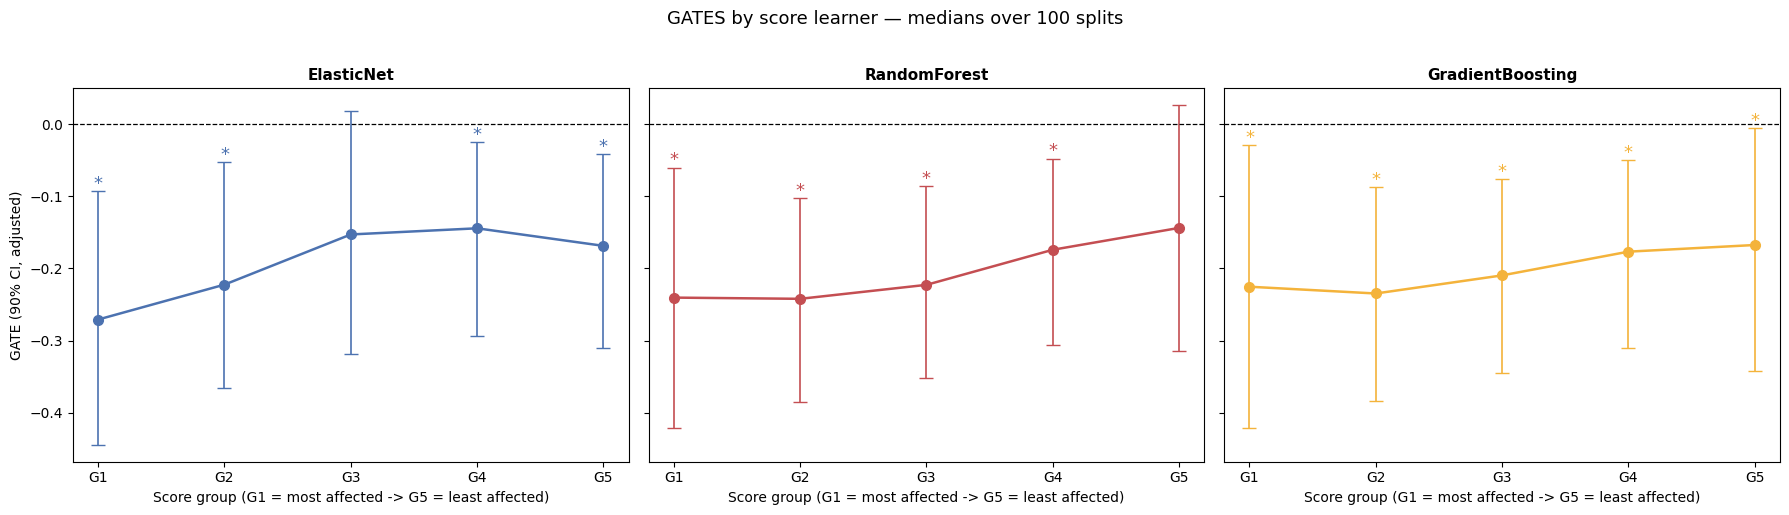

In [19]:
fig, axes = plt.subplots(1, len(SCORE_LEARNERS),
                         figsize=(6 * len(SCORE_LEARNERS), 5), sharey=True)
if len(SCORE_LEARNERS) == 1:
    axes = [axes]

for ax, name in zip(axes, SCORE_LEARNERS):
    color = COLORS[name]
    ga    = (all_results[name]['gates']
             .groupby('gate_group', observed=False)
             .agg(coef=('gamma_hat',   'median'),
                  ci_lo=('ci_lo_split', 'median'),
                  ci_hi=('ci_hi_split', 'median'),
                  p_adj=('pval', lambda s: min(1.0, 2*np.nanmedian(s))))
             .reset_index().sort_values('gate_group'))

    groups = ga['gate_group'].astype(str).tolist()
    coefs  = ga['coef'].values
    ax.errorbar(groups, coefs,
                yerr=[coefs - ga['ci_lo'].values, ga['ci_hi'].values - coefs],
                fmt='o-', color=color, capsize=5, linewidth=1.8,
                elinewidth=1.2, markersize=7)
    ax.axhline(0, linestyle='--', color='black', linewidth=0.9)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score group (G1 = most affected -> G5 = least affected)')
    if ax == axes[0]:
        ax.set_ylabel('GATE (90% CI, adjusted)')

    # Stars for significant groups (adjusted p < 0.10)
    for x_pos, (_, row) in enumerate(ga.iterrows()):
        if row['p_adj'] < 0.10:
            ax.text(x_pos, row['ci_hi'] + 0.003, '*',
                    ha='center', color=color, fontsize=13)

plt.suptitle('GATES by score learner — medians over 100 splits', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


### Interpretation — GATES

GATES show the estimated scholarship effect group by group, from the most affected (G1) to the least affected (G5) according to the score S(Z).

**Key points**:
- The effect is **negative in every group** — the scholarship reduces dropout for all profiles, without exception.
- The **ATE line** (≈ −0.15) runs through all groups, visually confirming the absence of strong heterogeneity.
- The G5 − G1 gap is approximately **−0.10 pp** (not significant, p ≈ 0.59 for RF), consistent with the BLP result.
- Confidence intervals are wide, especially for G1 and G5 — the extreme groups are smaller and more uncertain.

In short: the scholarship has a robust and generalised protective effect, but the score based on field of study, gender, and entry grades does not reveal a subgroup with a markedly different effect from the others.

## 17. GATES — distribution of split estimates (robustness)

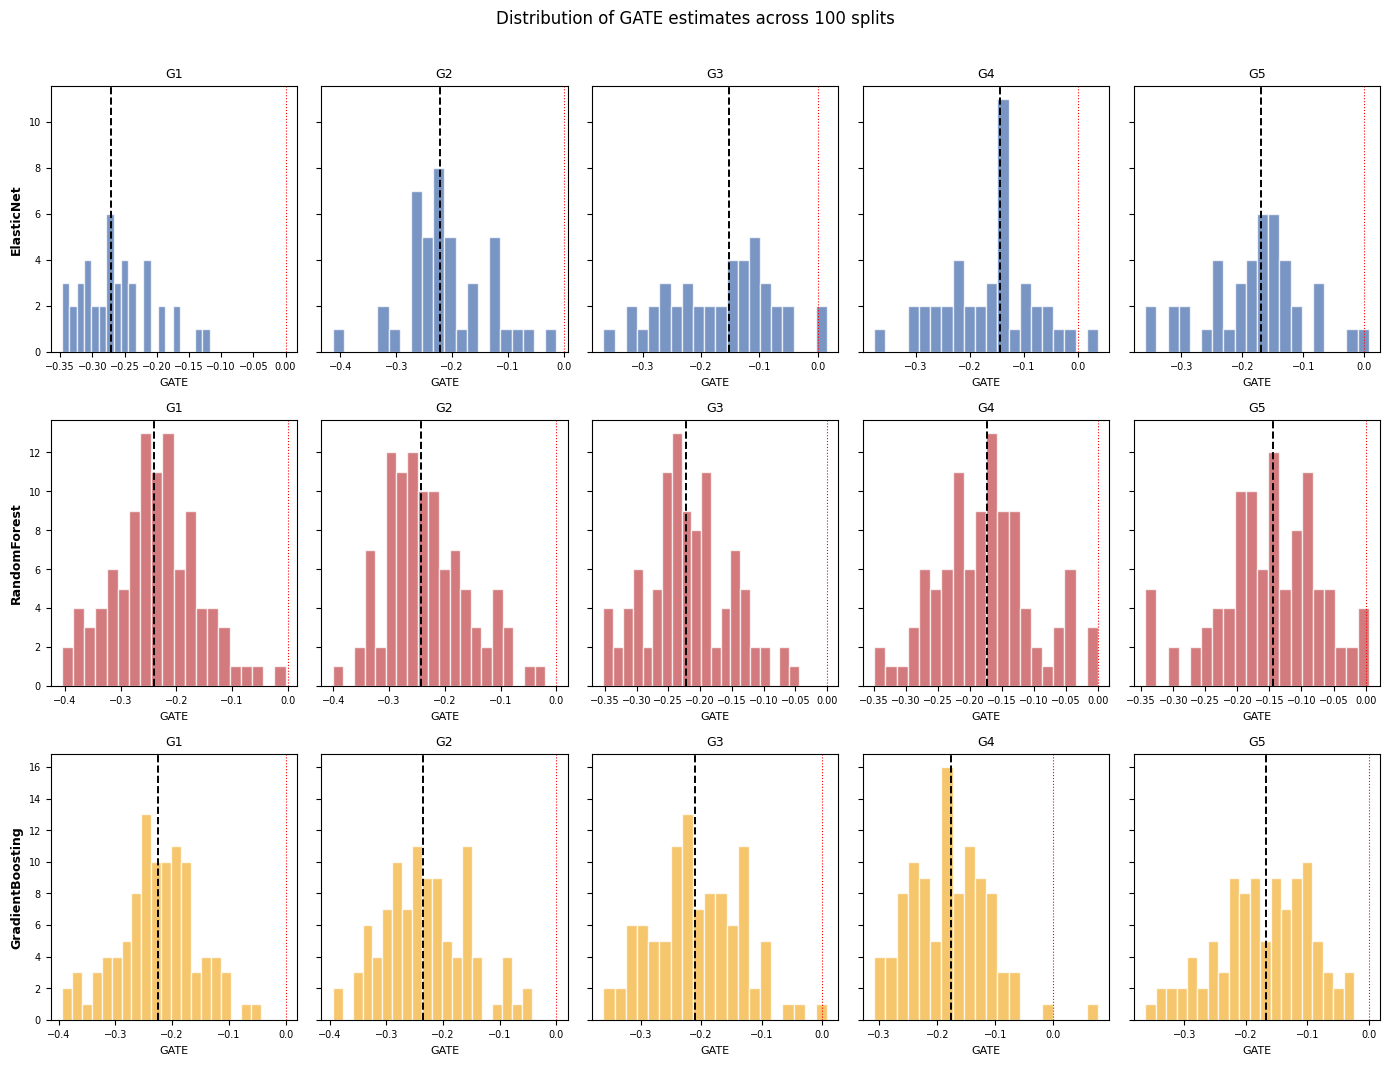

In [20]:
fig, axes = plt.subplots(len(SCORE_LEARNERS), 5,
                         figsize=(14, 3.5 * len(SCORE_LEARNERS)), sharey='row')
if len(SCORE_LEARNERS) == 1:
    axes = axes[np.newaxis, :]

for row_idx, name in enumerate(SCORE_LEARNERS):
    color = COLORS[name]
    gd    = all_results[name]['gates']
    for col_idx, grp in enumerate(['G1','G2','G3','G4','G5']):
        ax   = axes[row_idx, col_idx]
        vals = gd.loc[gd['gate_group']==grp, 'gamma_hat'].dropna()
        ax.hist(vals, bins=20, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(np.median(vals), color='black', linewidth=1.4, linestyle='--')
        ax.axvline(0, color='red', linewidth=0.8, linestyle=':')
        if col_idx == 0:
            ax.set_ylabel(name, fontsize=9, fontweight='bold')
        ax.set_title(grp, fontsize=9)
        ax.set_xlabel('GATE', fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle('Distribution of GATE estimates across 100 splits', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()


## 18. GATES — cross-learner comparison on the same axes

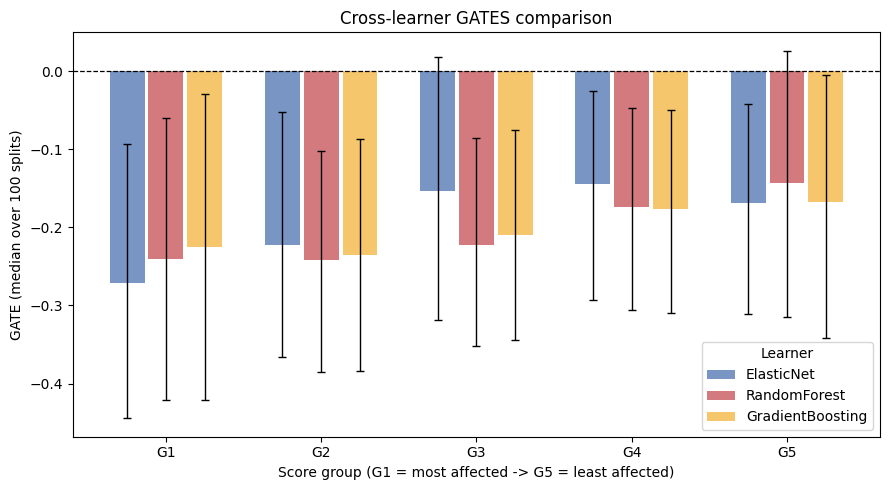

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
groups  = ['G1','G2','G3','G4','G5']
x       = np.arange(len(groups))
width   = 0.25
n_l     = len(SCORE_LEARNERS)
offsets = np.linspace(-(n_l-1)/2, (n_l-1)/2, n_l) * width

for (name, offset) in zip(SCORE_LEARNERS, offsets):
    color = COLORS[name]
    ga = (all_results[name]['gates']
          .groupby('gate_group', observed=False)
          .agg(coef=('gamma_hat', 'median'),
               ci_lo=('ci_lo_split', 'median'),
               ci_hi=('ci_hi_split', 'median'))
          .reindex(groups))
    coefs = ga['coef'].values
    ax.bar(x + offset, coefs, width*0.9, color=color, alpha=0.75, label=name)
    ax.errorbar(x + offset, coefs,
                yerr=[coefs - ga['ci_lo'].values, ga['ci_hi'].values - coefs],
                fmt='none', color='black', capsize=3, linewidth=1)

ax.axhline(0, linestyle='--', color='black', linewidth=0.9)
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_xlabel('Score group (G1 = most affected -> G5 = least affected)')
ax.set_ylabel('GATE (median over 100 splits)')
ax.set_title('Cross-learner GATES comparison')
ax.legend(title='Learner', framealpha=0.8)
plt.tight_layout(); plt.show()


### Interpretation — cross-learner GATES comparison

All three learners produce very similar GATES profiles, which is reassuring: the main finding (negative, homogeneous effect across all groups) is not an artefact of any particular learner.

ElasticNet produces a near-flat score (Var(S) ≈ 0), so its G1–G5 groups are nearly random — its GATES are essentially noise around the ATE, with very wide CIs. RF and GBT yield more structured groups but remain close to the ATE in each group.

The convergence across learners reinforces the conclusion: with these 4 X variables, detectable heterogeneity is weak.

## 19. β₂ distribution — strength of heterogeneity signal

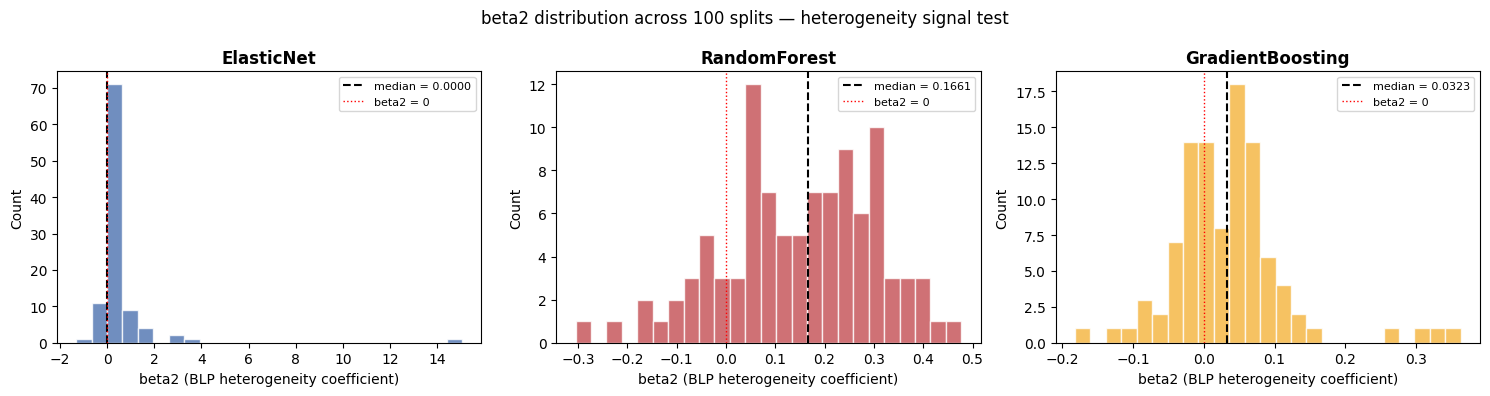

In [22]:
fig, axes = plt.subplots(1, len(SCORE_LEARNERS),
                         figsize=(5 * len(SCORE_LEARNERS), 4), sharey=False)
if len(SCORE_LEARNERS) == 1:
    axes = [axes]

for ax, name in zip(axes, SCORE_LEARNERS):
    color = COLORS[name]
    b2    = all_results[name]['splits']['beta2'].dropna()
    med   = np.median(b2)
    ax.hist(b2, bins=25, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(med, color='black', linewidth=1.5, linestyle='--',
               label=f'median = {med:.4f}')
    ax.axvline(0, color='red', linewidth=1, linestyle=':', label='beta2 = 0')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('beta2 (BLP heterogeneity coefficient)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('beta2 distribution across 100 splits — heterogeneity signal test', fontsize=12)
plt.tight_layout(); plt.show()


### Interpretation — β₂ distribution across 100 splits

The histograms show the distribution of β₂ across the 100 validation splits.

For **Random Forest** (the selected learner), the distribution of β₂ is centred slightly above 0 but massively overlaps 0 — confirming the non-significant p-value from the BLP.

For **ElasticNet**, the distribution is very spread out with many outliers — a sign that the score is unstable across splits (a direct consequence of the near-zero Var(S)).

For **GBT**, the distribution is the most concentrated around 0, reflecting a more regular score but an even weaker heterogeneity signal.

**Overall**: the median of β₂ is positive for all learners, suggesting a trend toward heterogeneity in the expected direction — but the signal is too weak to be distinguished from noise given the sample size and available variables.

## 20. CLAN — most vs least affected profiles

### Interpretation — CLAN (G1 vs G5 profiles)

**Note on score orientation**: S(Z) predicts φᵢ < 0 (the scholarship reduces dropout). Therefore, G1 (lowest S(Z) = most negative φ) groups the students **most affected** by the scholarship, and G5 the **least affected**. The axis is thus reversed relative to a positive CATE.

**Continuous variables** (median over 100 splits, RF):

| Variable | G1 (most affected) | G5 (least affected) | G5 − G1 |
|---|---|---|---|
| Admission grade | 122.9 | 132.5 | +9.5 |
| Previous qualification (grade) | 129.5 | 137.6 | +8.0 |
| Baseline dropout risk (μ₀) | 0.559 | 0.338 | −0.221 |

Students **most benefiting from the scholarship (G1)** have a high baseline dropout probability (μ₀ = 0.56) and lower entry grades — these are the most at-risk profiles, for whom financial support genuinely changes outcomes.

Students **least benefiting (G5)** have a low baseline risk (μ₀ = 0.34) and better grades — they would likely succeed with or without a scholarship, reducing its marginal effect.

This result is intuitively coherent: the scholarship has the greatest impact where the financial constraint is most determinative of academic trajectory — that is, among students who are already at risk.

**Targeting implication**: targeting high-risk profiles seems warranted. That said, the lack of statistical significance of β₂ calls for caution — this profile rests on a weak heterogeneity signal given these 4 variables.

CLAN — continuous/binary variables (RandomForest, medians over 100 splits):


,variable,mean_G1,mean_G5,diff,pval_adj,sig
0,Previous qualification (grade),128.6921,136.3446,7.6157,0.0,***
1,Admission grade,123.0648,130.3071,7.4402,0.0,***
2,baseline_risk_hat,0.5572,0.4028,-0.1446,0.0,***


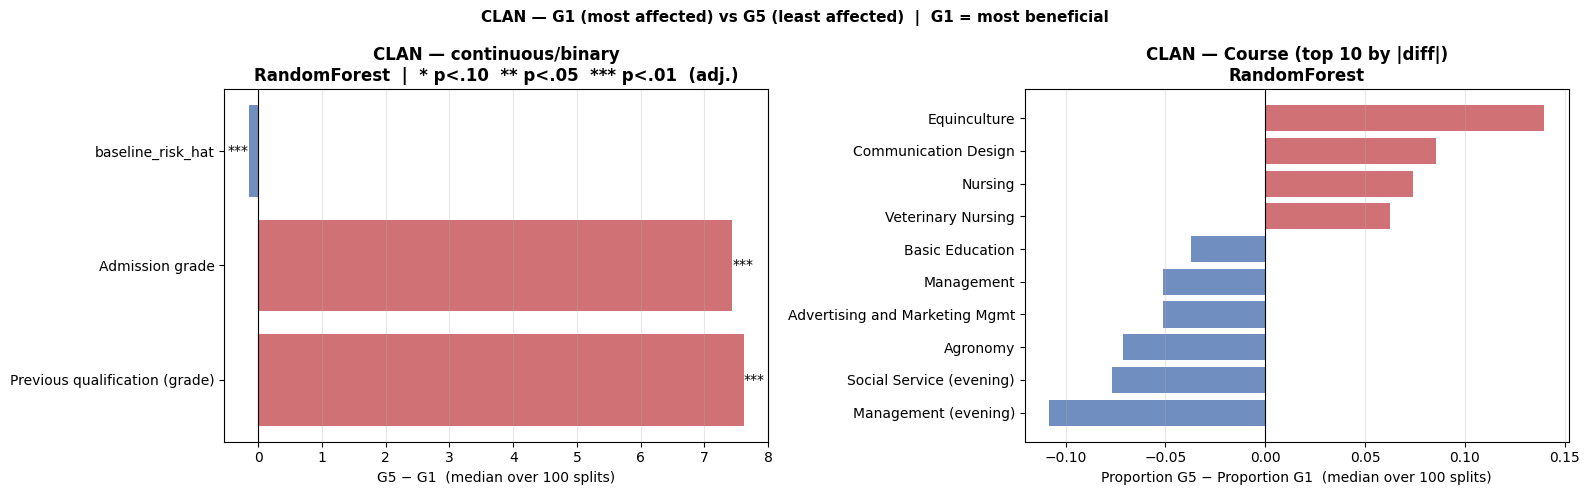

In [23]:
name = best_learner_name

# ── Left panel: continuous/binary variables ──────────────────────────────────
# Aggregate across 100 splits: median mean, median diff, median p-value (Welch t-test)
# Adjusted p-value = 2 × median raw p  (same split-sample convention as BLP/GATES)
clan_cont = (all_results[name]['clan']
             .groupby('variable')
             .agg(
                 mean_G5=('mean_G5', 'median'),
                 mean_G1=('mean_G1', 'median'),
                 diff=('diff_G5_minus_G1', 'median'),
                 pval_adj=('pval_raw', lambda s: min(1.0, 2 * np.nanmedian(s)))
             )
             .sort_values('diff', ascending=False)
             .reset_index())

# Stars: *** p<0.01, ** p<0.05, * p<0.10
def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '** '
    if p < 0.10:  return '*  '
    return '   '

clan_cont['sig'] = clan_cont['pval_adj'].apply(stars)
print(f'CLAN — continuous/binary variables ({name}, medians over 100 splits):')
display(clan_cont[['variable', 'mean_G1', 'mean_G5', 'diff', 'pval_adj', 'sig']].round(4))

# ── Right panel: Course proportions (top 10 modalities by |diff|) ────────────
clan_cat = (all_results[name]['clan_cat']
            .groupby(['variable', 'modality'])
            .agg(prop_G5=('prop_G5', 'median'),
                 prop_G1=('prop_G1', 'median'),
                 diff=('diff_G5_minus_G1', 'median'))
            .reset_index())

course_clan = (clan_cat[clan_cat['variable'] == 'Course']
               .assign(abs_diff=lambda d: d['diff'].abs())
               .sort_values('abs_diff', ascending=False)
               .head(10)
               .sort_values('diff', ascending=True)
               .assign(modality=lambda d:
                   d['modality'].map(lambda v: COURSE_NAMES.get(int(v), str(v)))))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: continuous CLAN — add significance annotation on bars
colors_cont = ['#C44E52' if d > 0 else '#4C72B0' for d in clan_cont['diff']]
bars = axes[0].barh(clan_cont['variable'], clan_cont['diff'], color=colors_cont, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
for i, (_, row) in enumerate(clan_cont.iterrows()):
    x_pos = row['diff'] + (0.002 if row['diff'] >= 0 else -0.002)
    ha = 'left' if row['diff'] >= 0 else 'right'
    axes[0].text(x_pos, i, row['sig'].strip(), va='center', ha=ha,
                 fontsize=10, color='black')
axes[0].set_xlabel('G5 − G1  (median over 100 splits)')
axes[0].set_title(f'CLAN — continuous/binary\n{name}  |  * p<.10  ** p<.05  *** p<.01  (adj.)',
                  fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Right: Course proportions
colors_course = ['#C44E52' if d > 0 else '#4C72B0' for d in course_clan['diff']]
axes[1].barh(course_clan['modality'].astype(str), course_clan['diff'],
             color=colors_course, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Proportion G5 − Proportion G1  (median over 100 splits)')
axes[1].set_title(f'CLAN — Course (top 10 by |diff|)\n{name}', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('CLAN — G1 (most affected) vs G5 (least affected)  |  G1 = most beneficial',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 21. Final summary table

In [24]:
sr = all_results[best_learner_name]['splits']
ga = (all_results[best_learner_name]['gates']
      .groupby('gate_group', observed=False)
      .agg(med=('gamma_hat', 'median'),
           ci_lo=('ci_lo_split', 'median'),
           ci_hi=('ci_hi_split', 'median'),
           p_adj=('pval', lambda s: round(min(1.0, 2*np.nanmedian(s)), 4)))
      .reset_index().sort_values('gate_group'))

print(f'Selected learner: {best_learner_name}')
print('BLP (medians over 100 splits, 90% CI):')
display(pd.DataFrame({
    'parameter':   ['beta1 (ATE component)', 'beta2 (heterogeneity)', 'G5-G1 gap'],
    'estimate':    [np.nanmedian(sr['beta1']), np.nanmedian(sr['beta2']), np.nanmedian(sr['gates_gap'])],
    'CI_lo_90':    [np.nanmedian(sr['beta1_ci_lo']), np.nanmedian(sr['beta2_ci_lo']), np.nanmedian(sr['gates_gap_ci_lo'])],
    'CI_hi_90':    [np.nanmedian(sr['beta1_ci_hi']), np.nanmedian(sr['beta2_ci_hi']), np.nanmedian(sr['gates_gap_ci_hi'])],
    'adj_pvalue':  [
        round(min(1.0, 2*np.nanmedian(sr['beta1_pval'])), 4),
        round(min(1.0, 2*np.nanmedian(sr['beta2_pval'])), 4),
        round(min(1.0, 2*np.nanmedian(sr['gates_gap_pval'])), 4),
    ],
}).round(4))

print('GATES:')
display(ga.round(4))


Selected learner: RandomForest
BLP (medians over 100 splits, 90% CI):


,parameter,estimate,CI_lo_90,CI_hi_90,adj_pvalue
0,beta1 (ATE component),-0.2080,-0.2763,-0.1378,0.0000
1,beta2 (heterogeneity),0.1661,-0.1345,0.4469,0.5504
2,G5-G1 gap,0.1005,-0.1656,0.3568,0.7556


GATES:


,gate_group,med,ci_lo,ci_hi,p_adj
0,G1,-0.2405,-0.4209,-0.0603,0.0183
1,G2,-0.2422,-0.3848,-0.1022,0.0019
2,G3,-0.2228,-0.3517,-0.0858,0.0029
3,G4,-0.1742,-0.3063,-0.0478,0.0091
4,G5,-0.1439,-0.3141,0.0260,0.1788


## 22. Save outputs

In [25]:
output_dir = Path('outputs_hte'); output_dir.mkdir(exist_ok=True)

for name in SCORE_LEARNERS:
    slug = name.lower().replace(' ', '_')
    all_results[name]['splits'].to_csv(output_dir / f'blp_splits_{slug}.csv',   index=False)
    all_results[name]['gates'].to_csv(output_dir  / f'gates_splits_{slug}.csv', index=False)
    all_results[name]['clan'].to_csv(output_dir   / f'clan_splits_{slug}.csv',  index=False)

blp_compare.to_csv(output_dir / 'blp_compare_learners.csv')
cf_data.to_csv(output_dir / 'part2_dr_score_fullsample.csv', index=False)
sel_df.to_csv(output_dir / 'learner_selection_criterion.csv')

print('Saved files:')
for p in sorted(output_dir.glob('*.csv')):
    print(' -', p.name)


Saved files:
 - blp_compare_learners.csv
 - blp_splits_elasticnet.csv
 - blp_splits_gradientboosting.csv
 - blp_splits_randomforest.csv
 - clan_splits_elasticnet.csv
 - clan_splits_gradientboosting.csv
 - clan_splits_randomforest.csv
 - gates_splits_elasticnet.csv
 - gates_splits_gradientboosting.csv
 - gates_splits_randomforest.csv
 - learner_selection_criterion.csv
 - part2_dr_score_fullsample.csv
